In [2]:
import xarray as xr
import os
import matplotlib.pyplot as plt

# Path to the NetCDF file
file_path = os.path.join("../data/era5/2023-04-01.nc")

# Check if the file exists
if os.path.exists(file_path):
    # Open the NetCDF file
    ds = xr.open_dataset(file_path)
    
    # Display basic information about the dataset
    print("Dataset Information:")
    print(f"Dimensions: {dict(ds.dims)}")
    print("\nCoordinates:")
    for name, coord in ds.coords.items():
        print(f"  - {name}: {coord.shape}")
    
    print("\nData Variables:")
    for name, var in ds.data_vars.items():
        print(f"  - {name}")
        print(f"    Dimensions: {var.dims}")
        print(f"    Shape: {var.shape}")
        print(f"    Attributes: {var.attrs}")
        print()
    
    # Display global attributes
    print("Global Attributes:")
    for attr_name, attr_value in ds.attrs.items():
        print(f"  {attr_name}: {attr_value}")
    
    # Close the dataset
    ds.close()
else:
    print(f"File not found: {file_path}")
    print("Please make sure you've downloaded the ECMWF data using the download_ecmwf_weather.py script.")


Dataset Information:
Dimensions: {'valid_time': 24, 'latitude': 169, 'longitude': 225, 'pressure_level': 2}

Coordinates:
  - valid_time: (24,)
  - latitude: (169,)
  - longitude: (225,)
  - number: ()
  - pressure_level: (2,)
  - expver: (24,)

Data Variables:
  - u10
    Dimensions: ('valid_time', 'latitude', 'longitude')
    Shape: (24, 169, 225)
    Attributes: {'GRIB_paramId': np.int64(165), 'GRIB_dataType': 'an', 'GRIB_numberOfPoints': np.int64(38025), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'instant', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(225), 'GRIB_Ny': np.int64(169), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'u10', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0),

/var/folders/8k/_h2zg_z51q9fpsbmsh42bd3h0000gn/T/ipykernel_13409/3008512586.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds.dims)}")


In [3]:
ds = xr.open_dataset(file_path)

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import cartopy.feature as cfeature

def plot_wind_map(ds, u_var='u10', v_var='v10', level=None, time_idx=0, 
                 projection=ccrs.PlateCarree(), figsize=(12, 8), 
                 quiver_stride=5, plot_type='quiver', scale=100,
                 title=None, extent=None):
    """
    Plot wind map using cartopy from xarray dataset.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing wind components
    u_var : str, default 'u10'
        Name of the U component variable
    v_var : str, default 'v10'
        Name of the V component variable
    level : int or None, default None
        Pressure level index if using 3D variables (u, v)
    time_idx : int, default 0
        Time index to plot
    projection : cartopy.crs, default ccrs.PlateCarree()
        Map projection to use
    figsize : tuple, default (12, 8)
        Figure size
    quiver_stride : int, default 5
        Stride/skipping factor for quiver arrows
    plot_type : str, default 'quiver'
        Type of plot ('quiver' or 'streamplot')
    scale : float, default 100
        Scale factor for quiver plot
    title : str or None, default None
        Plot title
    extent : list or None, default None
        Map extent [lon_min, lon_max, lat_min, lat_max]
        
    Returns:
    --------
    fig, ax : matplotlib Figure and Axes objects
    """
    
    # Create figure and axes with cartopy projection
    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(projection=projection))
    
    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.gridlines(draw_labels=True)
    
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Extract the data for the given time step
    time_dim = 'valid_time' if 'valid_time' in ds.dims else 'time'
    
    if level is not None and 'pressure_level' in ds.dims:
        # For 3D variables (u, v)
        u = ds[u_var].isel({time_dim: time_idx, 'pressure_level': level})
        v = ds[v_var].isel({time_dim: time_idx, 'pressure_level': level})
    else:
        # For 2D variables (u10, v10)
        u = ds[u_var].isel({time_dim: time_idx})
        v = ds[v_var].isel({time_dim: time_idx})
    
    # Get coordinates
    lons = u.longitude.values
    lats = u.latitude.values
    
    # Calculate wind speed for color mapping
    wind_speed = np.sqrt(u**2 + v**2)
    
    if plot_type == 'quiver':
        # Create a meshgrid for quiver plotting
        lon2d, lat2d = np.meshgrid(lons, lats)
        
        # Plot with quiver to show wind vectors
        q = ax.quiver(lon2d[::quiver_stride, ::quiver_stride], 
                     lat2d[::quiver_stride, ::quiver_stride],
                     u.values[::quiver_stride, ::quiver_stride], 
                     v.values[::quiver_stride, ::quiver_stride],
                     wind_speed.values[::quiver_stride, ::quiver_stride],
                     cmap='viridis',
                     scale=scale,
                     transform=ccrs.PlateCarree())
        
        plt.colorbar(q, ax=ax, label='Wind Speed (m/s)')
        
    elif plot_type == 'streamplot':
        # For streamplot, data must be on a regular grid
        speed = ax.contourf(lons, lats, wind_speed, 
                           transform=ccrs.PlateCarree(),
                           cmap='viridis')
        
        # Add streamlines
        strm = ax.streamplot(lons, lats, u.values, v.values,
                            density=1.5, color='white',
                            transform=ccrs.PlateCarree())
        
        plt.colorbar(speed, ax=ax, label='Wind Speed (m/s)')
    
    # Add title
    if title:
        plt.title(title)
    else:
        time_val = ds[time_dim].values[time_idx]
        plt.title(f'Wind Map at {time_val}')
    
    return fig, ax

(<Figure size 1200x800 with 2 Axes>,
 <GeoAxes: title={'center': 'Wind Map at 2023-04-01T16:00:00.000000000'}>)

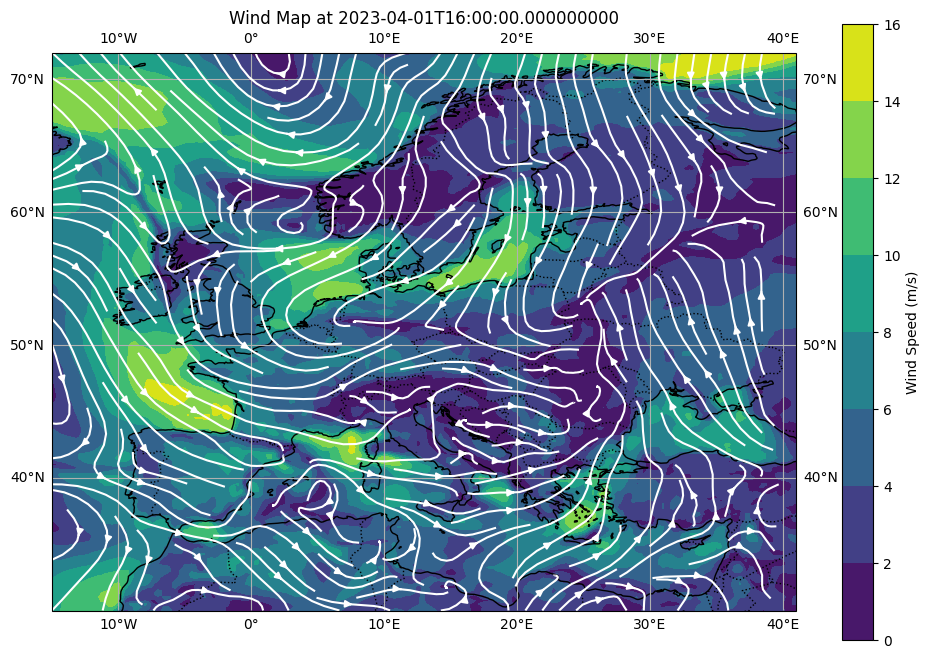

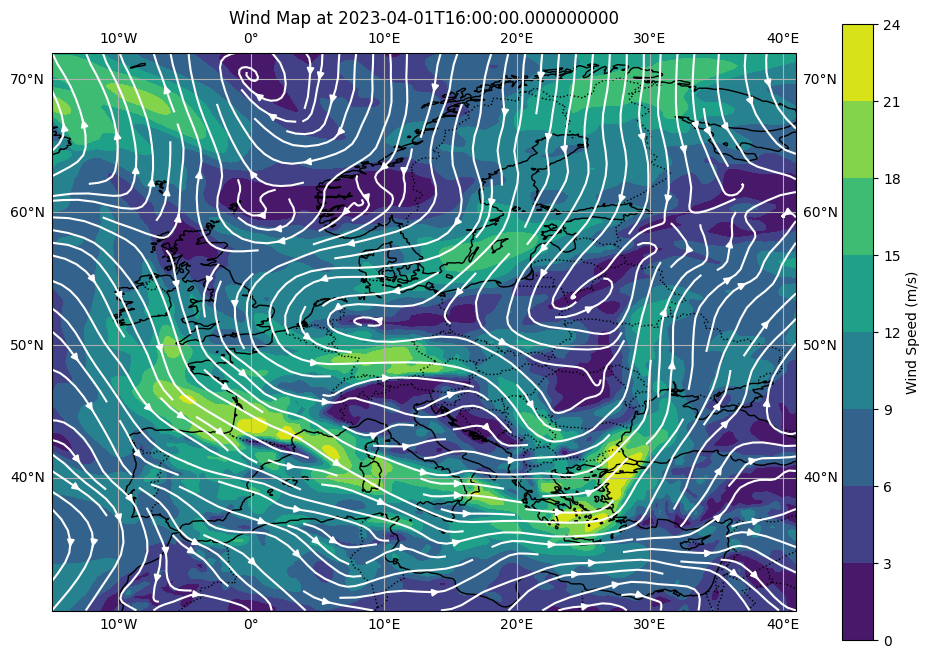

In [6]:
# For surface winds
plot_wind_map(ds, u_var='u10', v_var='v10', plot_type='streamplot', time_idx=16)

# For winds at a specific pressure level
plot_wind_map(ds, u_var='u', v_var='v', level=0, plot_type='streamplot', time_idx=16)

# Inspect Wind Interpolation

In [20]:
import networkx as nx 
G = nx.read_gml("../data/graph/LEMD_EGLL_2023_04_01.gml")
node_to_idx = {node: i for i, node in enumerate(G.nodes())}
idx_to_node = {i: node for i, node in enumerate(G.nodes())}


In [1]:
from equinox.wind.wind_date import WindDate 

wind_model = WindDate(date_str="2023-04-01", data_dir="../data/era5")


In [22]:
# Get the coordinates of LEMD and LETO
lemd = (G.nodes['LEMD']['lat'], G.nodes['LEMD']['lon'])
leto = (G.nodes['LETO']['lat'], G.nodes['LETO']['lon'])

In [ ]:
# @ground level
import datetime
wind_lemd_0_mps = wind_model.get_wind_components(lemd[0], lemd[1], 0, datetime.datetime(2024, 4, 1, 10, 15, 0))
wind_lemd_200_mps = wind_model.get_wind_components(lemd[0], lemd[1], 35000, datetime.datetime(2024, 4, 1, 10, 15, 0))
print(f"Wind at LEMD at ground level: {wind_lemd_0_mps}")
print(f"Wind at LEMD at 35000 ft: {wind_lemd_200_mps}")

In [ ]:
# @ground level for LETO
import datetime
wind_leto_0_mps = wind_model.get_wind_components(leto[0], leto[1], 0, datetime.datetime(2024, 4, 1, 10, 15, 0))
wind_leto_200_mps = wind_model.get_wind_components(leto[0], leto[1], 35000, datetime.datetime(2024, 4, 1, 10, 15, 0))
print(f"Wind at LETO at ground level: {wind_leto_0_mps}")
print(f"Wind at LETO at 35000 ft: {wind_leto_200_mps}")

In [25]:
def print_wind_at_location(ds, lat, lon, u_var='u', v_var='v', level=0, time_idx=0):
    """
    Print wind values at a specific location and level from xarray dataset.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing wind components
    lat : float
        Latitude coordinate
    lon : float
        Longitude coordinate
    u_var : str, default 'u10'
        Name of the U component variable
    v_var : str, default 'v10'
        Name of the V component variable
    level : int, default 0
        Pressure level index (0 for surface level)
    time_idx : int, default 0
        Time index
        
    Returns:
    --------
    None (prints values)
    """
    
    # Determine time dimension name
    time_dim = 'valid_time' if 'valid_time' in ds.dims else 'time'
    
    try:
        # Check if we have 3D variables with pressure levels
        if 'pressure_level' in ds.dims and level is not None:
            # For 3D variables (u, v) - select level 0
            u_data = ds[u_var].isel({time_dim: time_idx, 'pressure_level': level})
            v_data = ds[v_var].isel({time_dim: time_idx, 'pressure_level': level})
        else:
            # For 2D variables (u10, v10) - no level selection needed
            u_data = ds[u_var].isel({time_dim: time_idx})
            v_data = ds[v_var].isel({time_dim: time_idx})
        
        # Select nearest point to the given lat/lon
        u_point = u_data.sel(latitude=lat, longitude=lon, method='nearest')
        v_point = v_data.sel(latitude=lat, longitude=lon, method='nearest')
        
        # Calculate wind speed and direction
        u_val = float(u_point.values)
        v_val = float(v_point.values)
        wind_speed = np.sqrt(u_val**2 + v_val**2)
        wind_direction = np.arctan2(v_val, u_val) * 180 / np.pi
        
        # Get actual coordinates used (nearest grid point)
        actual_lat = float(u_point.latitude.values)
        actual_lon = float(u_point.longitude.values)
        
        # Get time value
        time_val = ds[time_dim].values[time_idx]
        
        # Print results
        print(f"Wind values at nearest grid point:")
        print(f"Requested: lat={lat}, lon={lon}")
        print(f"Actual: lat={actual_lat:.2f}, lon={actual_lon:.2f}")
        print(f"Time: {time_val}")
        if 'pressure_level' in ds.dims and level is not None:
            pressure_val = ds.pressure_level.values[level]
            print(f"Pressure level: {pressure_val} hPa")
        print(f"U component ({u_var}): {u_val:.2f} m/s")
        print(f"V component ({v_var}): {v_val:.2f} m/s")
        print(f"Wind speed: {wind_speed:.2f} m/s")
        print(f"Wind direction: {wind_direction:.1f}°")
        
    except KeyError as e:
        print(f"Error: Variable not found in dataset - {e}")
    except Exception as e:
        print(f"Error accessing wind data: {e}")

In [ ]:
print_wind_at_location(ds, lemd[0], lemd[1], time_idx=10)